#1. Entendimeinto del negocio

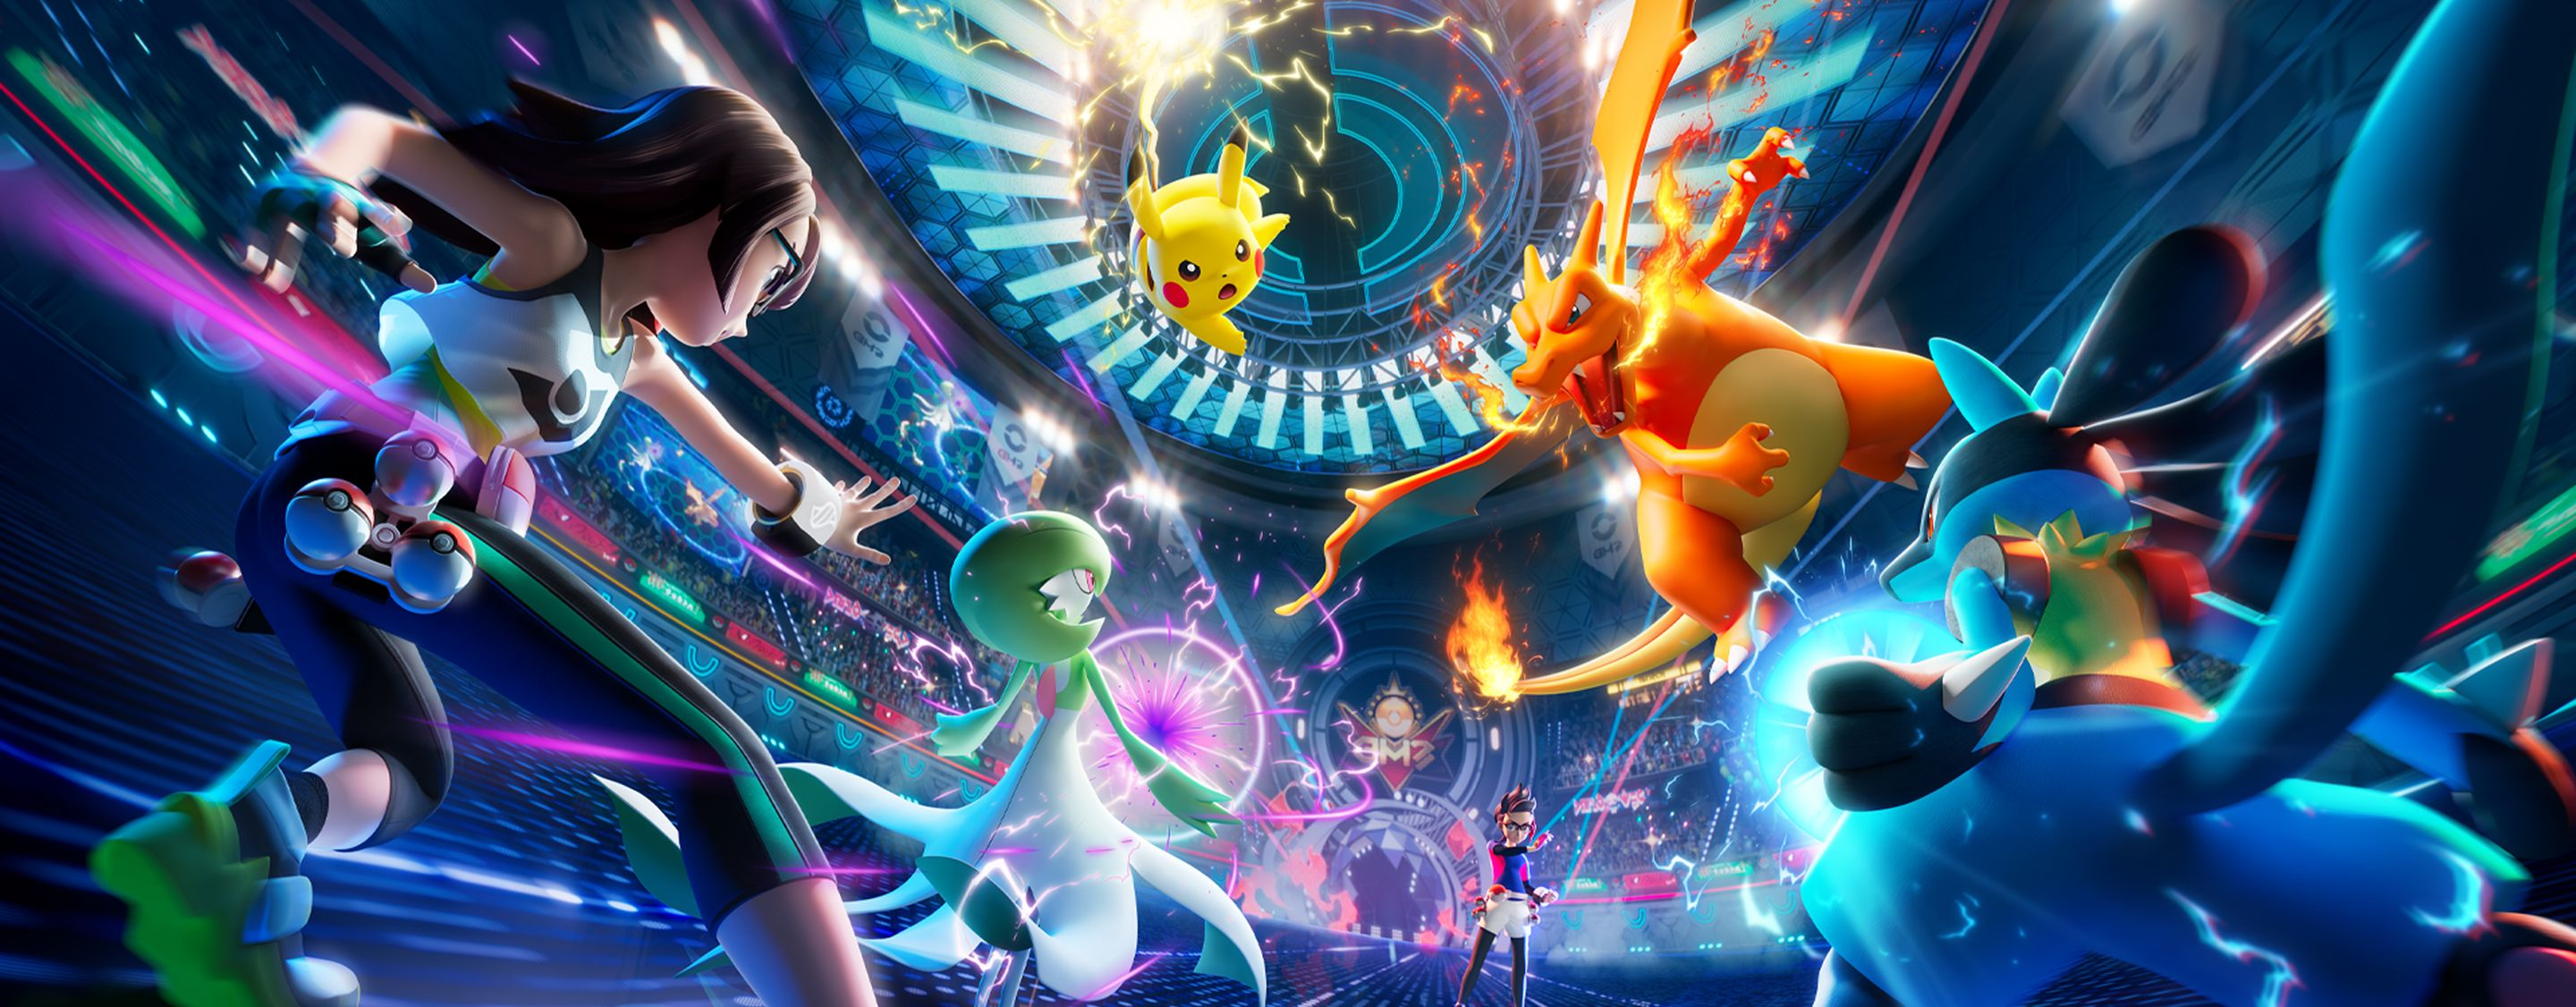

Pokémon Champions se plantea como un entorno competitivo donde entrenadores seleccionan equipos o dúos de Pokémon para enfrentarse estratégicamente utilizando estadísticas base, tipos, velocidad, resistencia y complementariedad táctica. Aunque el rendimiento real en combate depende también de movimientos, habilidades, objetos y decisiones del jugador, las estadísticas estructurales permiten construir una base analítica sólida para estimar qué combinaciones presentan mayores probabilidades de éxito.

En este proyecto, el análisis se centra en identificar cómo los atributos cuantitativos de cada Pokémon (HP, Atk, Def, SpA, SpD, Spe y Total), junto con variables estratégicas como tipos primarios/secundarios, pueden utilizarse para evaluar qué dúos poseen mejores probabilidades teóricas de ganar enfrentamientos.

A diferencia de un análisis descriptivo tradicional, este enfoque busca aproximarse a un sistema competitivo tipo team-builder, donde el objetivo no es solo evaluar individuos, sino comprender sinergias entre compañeros.

##1.2 Problema de negocio

Dentro de Pokémon Champions, elegir correctamente una combinación de Pokémon puede determinar la ventaja estratégica de un entrenador incluso antes del combate.

Sin embargo, no siempre es evidente qué factores influyen más en el potencial competitivo de un dúo:

¿Mayor poder total garantiza mejores resultados?

¿La velocidad tiene más peso que la defensa?

¿Es mejor combinar roles ofensivos y defensivos?

¿Qué importancia tiene la cobertura de tipos?

El problema de negocio de este proyecto consiste en:

Determinar qué variables estadísticas y estratégicas influyen de forma más significativa en la probabilidad teórica de victoria de un dúo de Pokémon, y desarrollar modelos analíticos que permitan identificar combinaciones óptimas.


Resolver este problema permite:

Diseñar mejores estrategias de selección.

Detectar patrones competitivos.

Optimizar combinaciones ofensivas, defensivas o balanceadas.

Construir sistemas predictivos aplicables a team building.

##1.3 Objetivos del proyecto

###1.3.1 Objetivo general

Analizar estadísticas base y variables estratégicas de Pokémon para identificar los factores que más influyen en el rendimiento competitivo de dúos, desarrollando modelos analíticos capaces de estimar probabilidad de victoria.



###1.3.2 Objetivos específicos



Analizar la distribución de estadísticas base dentro del ecosistema competitivo.

Evaluar la relación entre atributos ofensivos, defensivos y velocidad.

Identificar patrones entre tipos y potencial competitivo.

Construir indicadores compuestos como Offensive Score, Defensive Score y Duo Synergy Index.

Generar combinaciones de dúos y rankearlas según desempeño teórico.

Preparar los datos para modelos predictivos de regresión y clasificación.

Implementar modelos de Machine Learning orientados a estimar desempeño competitivo.

##1.4 Alcance y limitaciones del análisis

###1.4.1 Alcance

Este análisis considera:

Stats base oficiales
Tipos primarios y secundarios
Poder total
Sinergia estructural entre dúos
Cobertura estadística teórica

###1.4.2 Limitaciones

No considera:

Movesets específicos
EVs / IVs
Naturalezas
Objetos equipados
Decisiones humanas en combate
Meta competitivo dinámico

Por lo tanto, los resultados representan una aproximación estructural y estratégica, no una simulación exacta de batalla.

##1.5 Preguntas de negocio

¿Qué stats influyen más en el éxito competitivo?

¿Qué combinación de roles genera mejores resultados?

¿Qué tipos ofrecen mayor sinergia en dúos?

¿Es preferible priorizar velocidad o bulk?

¿Qué dúos presentan mejores probabilidades teóricas de victoria?

#2. Comprensión de los Datos

##2.1 Estructura del Dataset

El dataset corresponde a una Pokédex estructurada donde cada fila representa un Pokémon o forma específica, incluyendo variables numéricas, categóricas y estratégicas.


En esta etapa se realizará la carga del dataset y la importación de librerías necesarias para el análisis.

####Importación de librerías


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

se importan las librerias que se va a usar a lo largo de todo el analisis

##### Carga del dataset

In [ ]:
df = pd.read_csv("Updated_Dex_Final.csv")

# Visualización inicial
display(df.head(1000))

,NatDex,Pokemon,HP,Atk,Def,SpA,SpD,Spe,Total,Type I,Type II,Ability I,Ability II,Hidden Ability,EV Worth,Gender,Egg Group I,Egg Group II,Catch,Evolve
0,1,Bulbasaur,45,49,49,65,65,45,318.0,Grass,Poison,Overgrow,NaN,Chlorophyll,1 SpA,M (87.5%),Monster,Grass,45,NaN
1,2,Ivysaur,60,62,63,80,80,60,405.0,Grass,Poison,Overgrow,NaN,Chlorophyll,1 SpA/1 SpD,M (87.5%),Monster,Grass,45,Lv. 16
2,3,Mega Venusaur,80,100,123,122,120,80,625.0,Grass,Poison,Thick Fat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Venusaur,80,82,83,100,100,80,525.0,Grass,Poison,Overgrow,NaN,Chlorophyll,2 SpA/1 SpD,M (87.5%),Monster,Grass,45,Lv. 32
4,4,Charmander,39,52,43,60,50,65,309.0,Fire,NaN,Blaze,NaN,Solar Power,1 Spe,M (87.5%),Monster,Dragon,45,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,800,DW Necrozma,97,113,109,157,127,77,680.0,Psychic,Ghost,Prism Armor,NaN,NaN,3 SpA,NaN,NaN,NaN,NaN,N
996,800,Necrozma,97,107,101,127,89,79,600.0,Psychic,NaN,Prisim Armor,NaN,NaN,"1 Atk, 2 SpA",NaN,-,NaN,255,N
997,801,Mega Magearna,80,125,115,170,115,95,700.0,Steel,Fairy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,801,Magearna,80,95,115,130,115,65,600.0,Steel,Fairy,Soul Heart,NaN,NaN,3 SpA,NaN,-,NaN,3,N


Muestra las primeras 5 filas del dataset para verificar que los datos se cargaron correctamente.

###Variables principales:


Numéricas:

HP
Atk
Def
SpA
SpD
Spe
Total
Catch Rate

Categóricas:

Pokémon
Type I
Type II
Ability I
Ability II
Hidden Ability
Egg Groups

##Unidad de análisis: Cada registro representa una entidad competitiva evaluable individualmente.

##2.2 Estadísticas descriptivas básicas

En esta fase se analizará:

Media y mediana de stats

Desviación estándar

Distribución de velocidad

Distribución de poder total

Ranking ofensivo y defensivo

###Objetivo: Comprender cómo se distribuye el poder competitivo entre Pokémon.

In [ ]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NatDex          1237 non-null   object 
 1   Pokemon         1237 non-null   object 
 2   HP              1237 non-null   int64  
 3   Atk             1237 non-null   int64  
 4   Def             1237 non-null   int64  
 5   SpA             1237 non-null   int64  
 6   SpD             1237 non-null   int64  
 7   Spe             1237 non-null   int64  
 8   Total           1236 non-null   float64
 9   Type I          1237 non-null   object 
 10  Type II         689 non-null    object 
 11  Ability I       1213 non-null   object 
 12  Ability II      564 non-null    object 
 13  Hidden Ability  923 non-null    object 
 14  EV Worth        1146 non-null   object 
 15  Gender          968 non-null    object 
 16  Egg Group I     1024 non-null   object 
 17  Egg Group II    275 non-null    o

(1237, 20)

##Interpretación de resultados

El dataset contiene un total de 1237 registros y 20 variables, lo que representa una cantidad adecuada de información para realizar análisis competitivos dentro de Pokémon Champions.

A nivel estructural, se identificaron tres tipos principales de datos:

- Variables numéricas enteras (`int64`)
- Variables numéricas decimales (`float64`)
- Variables categóricas (`object`)

Las variables numéricas corresponden principalmente a estadísticas base de combate como HP, Atk, Def, SpA, SpD y Spe, las cuales serán fundamentales para el análisis competitivo y entrenamiento de modelos de Machine Learning.

Además, la variable `Total` aparece como tipo `float64`, debido a la presencia de valores faltantes dentro de la columna.

Por otro lado, se identificó una alta presencia de variables categóricas relacionadas con tipos, habilidades, evolución y grupos huevo, las cuales podrían aportar información estratégica relevante para futuros análisis de sinergia entre Pokémon.

Respecto a la calidad de datos, se detectaron valores faltantes en columnas como:

- Type II
- Ability II
- Egg Group II
- Evolve

Sin embargo, estos valores nulos no necesariamente representan errores, ya que muchos Pokémon poseen únicamente un tipo o una habilidad principal.

Finalmente, el tamaño del dataset resulta suficiente para desarrollar análisis exploratorios, clasificación competitiva y modelos predictivos dentro del contexto de Pokémon Champions.

In [ ]:
df.describe()

,HP,Atk,Def,SpA,SpD,Spe,Total
count,1237.000000,1237.000000,1237.000000,1237.000000,1237.000000,1237.000000,1236.000000
mean,71.270816,82.400162,75.753436,74.671787,73.474535,70.671787,448.435275
std,26.799149,32.820278,30.966991,34.109105,28.205534,30.583124,123.390069
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000
25%,54.000000,59.000000,54.000000,50.000000,52.000000,46.000000,335.000000
50%,70.000000,80.000000,70.000000,68.000000,70.000000,70.000000,470.000000
75%,85.000000,102.000000,95.000000,95.000000,90.000000,92.000000,530.000000
max,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000


##Análisis estadístico descriptivo

A partir de las estadísticas descriptivas obtenidas, se observa que los valores promedio de las estadísticas base se encuentran relativamente equilibrados entre ataque, defensa y velocidad.

La media del atributo `Total` supera los 430 puntos, indicando que gran parte de los Pokémon del dataset poseen estadísticas competitivas moderadas o altas.

También se identificó una amplia dispersión entre valores mínimos y máximos, especialmente en variables ofensivas y de velocidad, lo que sugiere la presencia de Pokémon extremadamente fuertes o especializados.

Por ejemplo:

- Algunos Pokémon poseen velocidades superiores a 180 puntos.
- Otros presentan estadísticas defensivas considerablemente bajas.
- Existen diferencias importantes entre Pokémon comunes y legendarios.

Estas variaciones serán relevantes durante el análisis exploratorio y la detección de outliers competitivos.

##2.3 Análisis exploratorio de datos (EDA)

###2.3.1 Distribución de poder total

Se analizará la dispersión del atributo Total para identificar Pokémon promedio, élite y outliers competitivos.

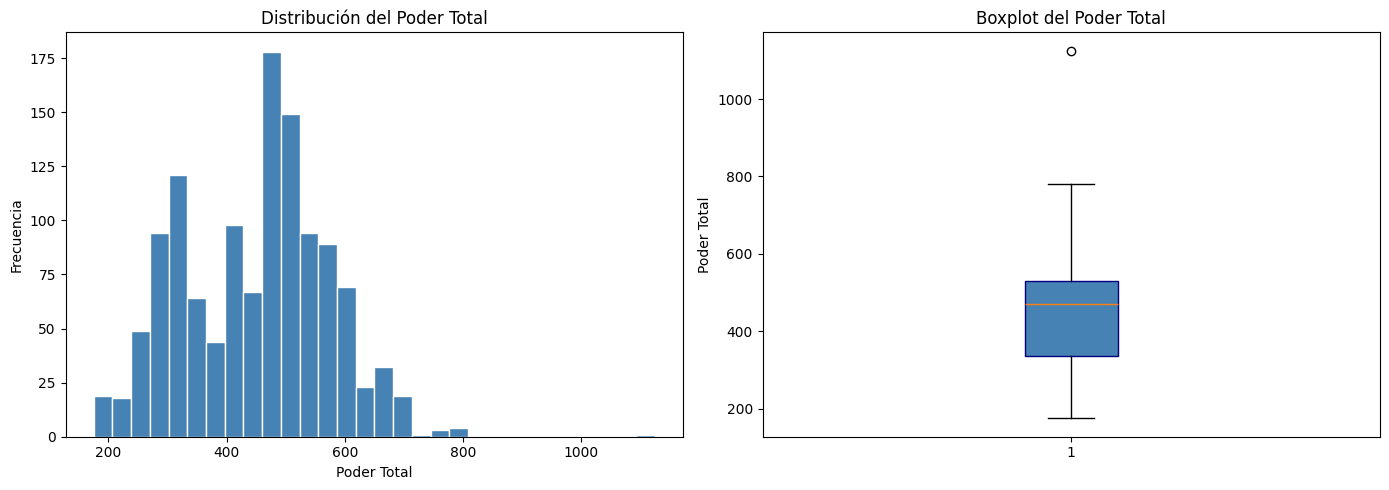

count    1236.000000
mean      448.435275
std       123.390069
min       175.000000
25%       335.000000
50%       470.000000
75%       530.000000
max      1125.000000
Name: Total, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Total'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Poder Total')
axes[0].set_xlabel('Poder Total')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['Total'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot del Poder Total')
axes[1].set_ylabel('Poder Total')

plt.tight_layout()
plt.show()

print(df['Total'].describe())

### Interpretación — Distribución del Poder Total

A partir del histograma y boxplot obtenidos, se pueden extraer las siguientes
observaciones sobre la distribución del poder total en el dataset:

**Distribución general:**  
La distribución del atributo `Total` presenta una forma aproximadamente bimodal
con sesgo positivo (hacia la derecha). Se observa una concentración principal de
Pokémon entre los 300 y 550 puntos, con un pico dominante alrededor de los 500
puntos, seguido de una segunda concentración menor entre 550 y 650 puntos,
posiblemente correspondiente a Pokémon Mega y legendarios.

**Estadísticas descriptivas:**
- La media del `Total` es aproximadamente **448 puntos**, ligeramente por debajo
  de la mediana (**470 puntos**), lo que confirma el sesgo positivo de la distribución.
- El 50% central de los Pokémon se concentra entre **335 y 530 puntos**
  (rango intercuartílico de 195 puntos).
- El valor mínimo registrado es **175 puntos** y el máximo es **1125 puntos**.

**Outliers:**  
El boxplot revela la presencia de al menos un outlier extremo superior, con un valor
cercano a **1125 puntos**, correspondiente a formas especiales o Pokémon Mega de
alto poder competitivo. Estos valores atípicos deberán considerarse durante el
modelado, ya que pueden distorsionar modelos sensibles a la escala.

**Implicación competitiva (Pokémon Champions):**  
Para el contexto del proyecto, la mayoría de los Pokémon disponibles poseen un
`Total` entre 400 y 550 puntos, lo que define el rango competitivo estándar.
Los Pokémon con `Total` superior a 600 puntos representan casos excepcionales
que podrían dominar el meta si no se establecen restricciones de selección.

###2.3.2 Distribución de Velocidad Competitiva

La velocidad (`Spe`) determina qué Pokémon actúa primero en el turno, siendo una de las variables más decisivas en el meta competitivo. Un Pokémon más rápido puede atacar, infligir estado o retirarse antes de recibir daño.

Se analizará su distribución para identificar umbrales competitivos clave.

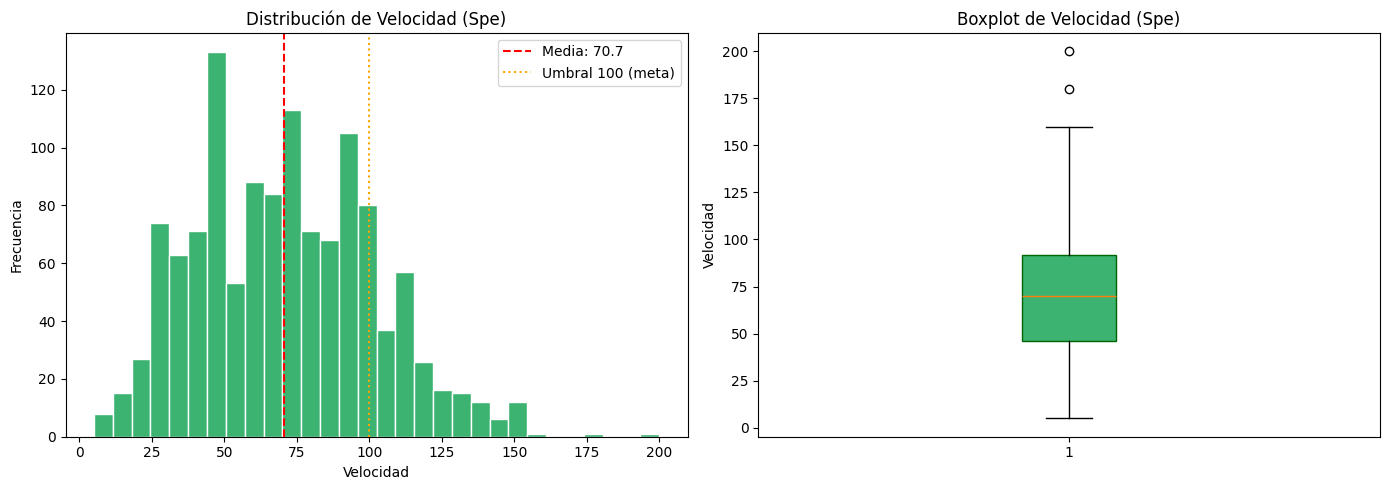

count    1237.000000
mean       70.671787
std        30.583124
min         5.000000
25%        46.000000
50%        70.000000
75%        92.000000
max       200.000000
Name: Spe, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Spe'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribución de Velocidad (Spe)')
axes[0].set_xlabel('Velocidad')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['Spe'].mean(), color='red', linestyle='--', label=f"Media: {df['Spe'].mean():.1f}")
axes[0].axvline(100, color='orange', linestyle=':', label='Umbral 100 (meta)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Spe'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', color='darkgreen'))
axes[1].set_title('Boxplot de Velocidad (Spe)')
axes[1].set_ylabel('Velocidad')

plt.tight_layout()
plt.show()

print(df['Spe'].describe())


### Interpretación — Distribución de Velocidad

La distribución de la velocidad (`Spe`) presenta un sesgo positivo moderado, con la mayor concentración de Pokémon entre los 50 y 100 puntos.

**Umbrales competitivos:**
- Los Pokémon con velocidad superior a **100** se consideran rápidos en el meta estándar, pudiendo actuar antes que la mayoría de oponentes.
- Velocidades superiores a **130** corresponden a sweepers de élite.
- El boxplot confirma la presencia de outliers superiores con velocidades extremas (>180), los cuales pertenecen a formas Mega o Pokémon diseñados específicamente para control de turnos.

**Implicación para Pokémon Champions:**
La velocidad es un factor diferenciador clave al armar dúos. Un dúo con al menos un Pokémon de alta velocidad tiene ventaja táctica para ejecutar estrategias de primer turno.

###2.3.3 Relación entre Ataque, Defensa y Velocidad

Analizar la relación entre variables ofensivas, defensivas y velocidad permite identificar arquetipos competitivos:

- **Sweepers**: alto Atk/SpA y alta Spe, baja Def
- **Tanks**: alta HP/Def/SpD, baja Spe
- **Balanced**: stats distribuidas uniformemente
- **Glass Cannons**: ataque extremo, defensa muy baja

Se utilizarán scatterplots y un heatmap de correlación para visualizar estas relaciones.

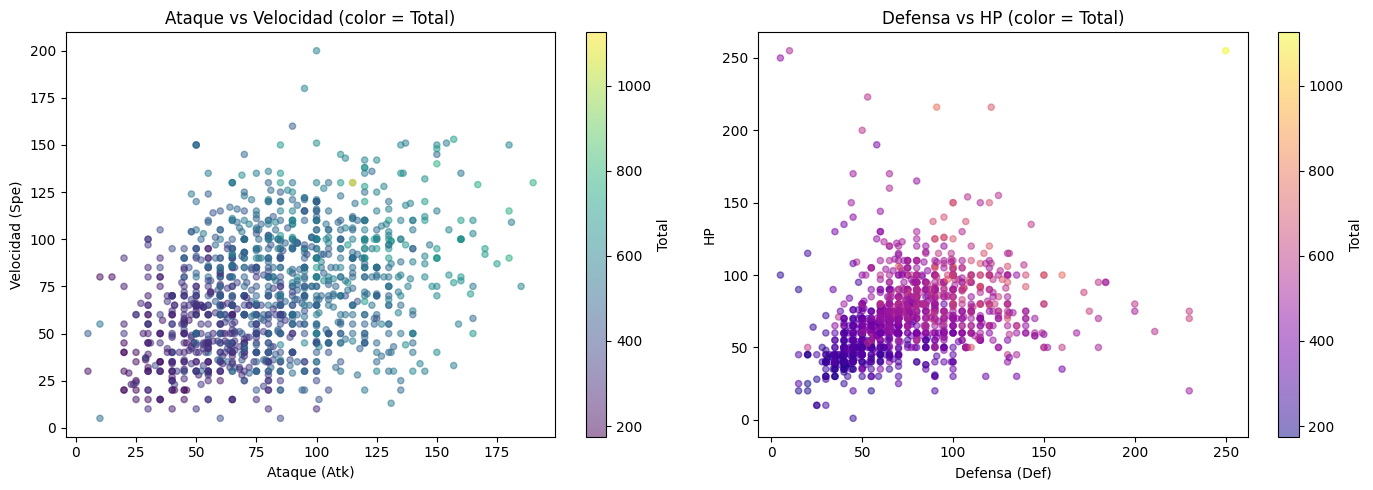

In [ ]:
# Scatterplot: Ataque vs Velocidad coloreado por Total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(df['Atk'], df['Spe'], c=df['Total'], cmap='viridis', alpha=0.5, s=20)
axes[0].set_title('Ataque vs Velocidad (color = Total)')
axes[0].set_xlabel('Ataque (Atk)')
axes[0].set_ylabel('Velocidad (Spe)')
plt.colorbar(sc1, ax=axes[0], label='Total')

# Scatterplot: Defensa vs HP coloreado por Total
sc2 = axes[1].scatter(df['Def'], df['HP'], c=df['Total'], cmap='plasma', alpha=0.5, s=20)
axes[1].set_title('Defensa vs HP (color = Total)')
axes[1].set_xlabel('Defensa (Def)')
axes[1].set_ylabel('HP')
plt.colorbar(sc2, ax=axes[1], label='Total')

plt.tight_layout()
plt.show()


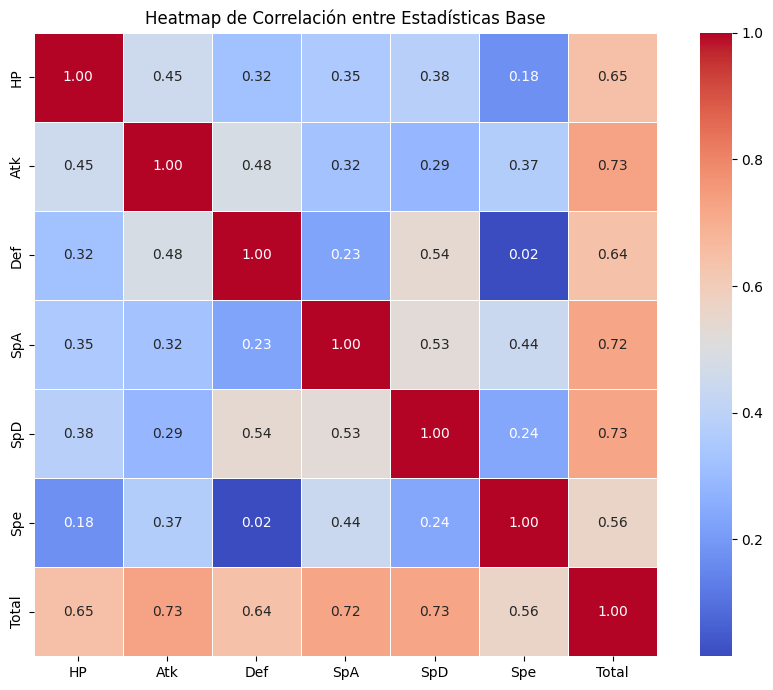

In [ ]:
# Heatmap de correlación entre stats numéricas
stats_cols = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe', 'Total']
corr_matrix = df[stats_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap de Correlación entre Estadísticas Base')
plt.tight_layout()
plt.show()


### Interpretación — Relación entre Stats y Heatmap de Correlación

**Scatterplots:**
- La relación entre Ataque y Velocidad muestra una nube dispersa sin correlación lineal fuerte, lo que indica que existen tanto Pokémon rápidos con alto ataque (sweepers) como lentos con alto ataque (tanks físicos).
- Los puntos más brillantes (mayor `Total`) tienden a concentrarse en regiones de stats altas, confirmando que el poder global se distribuye en múltiples perfiles.

**Heatmap:**
- `Total` presenta correlación positiva moderada-alta con todas las stats individuales, lo cual es esperado dado que es su suma.
- `Atk` y `SpA` muestran correlación débil entre sí, confirmando que existen Pokémon físicos, especiales y mixtos como arquetipos diferenciados.
- `Def` y `SpD` presentan correlación moderada, lo que sugiere que los Pokémon defensivos tienden a ser bulky en ambas dimensiones.

Estos patrones de correlación serán útiles para el feature engineering en la fase de preparación.

###2.3.4 Distribución por Tipos y Cobertura

El tipo primario (`Type I`) es una de las variables estratégicas más importantes en combate, ya que define resistencias, debilidades y STAB (Same Type Attack Bonus).

Se analizará la frecuencia de tipos para comprender la diversidad del meta y la cobertura ofensiva disponible al armar dúos.

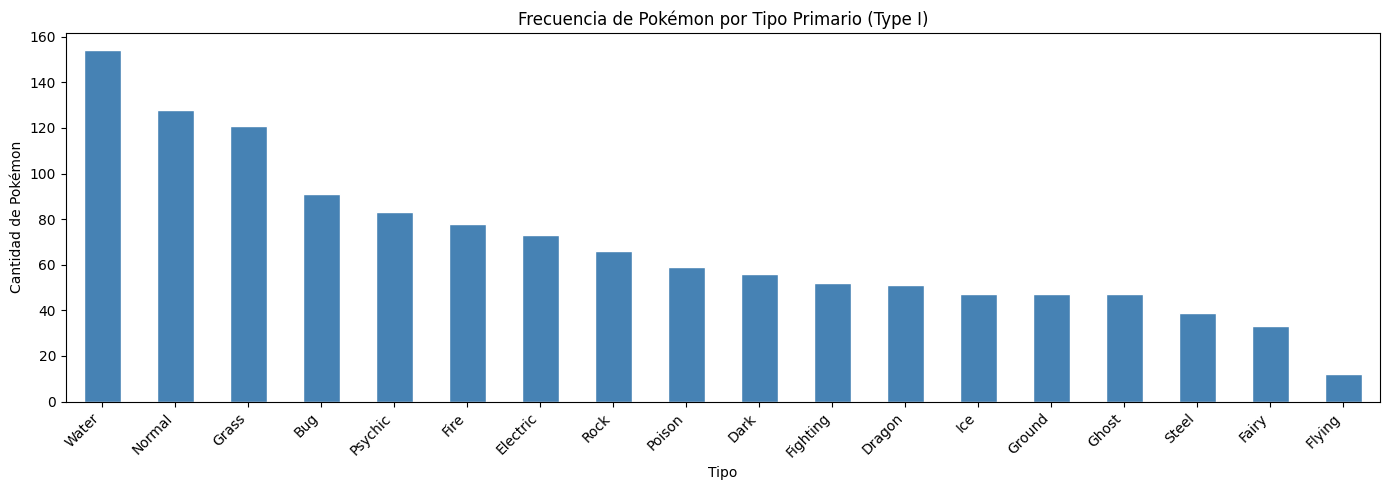


Top 5 tipos más frecuentes:
Type I
Water      154
Normal     128
Grass      121
Bug         91
Psychic     83
Name: count, dtype: int64

Top 5 tipos menos frecuentes:
Type I
Ground    47
Ghost     47
Steel     39
Fairy     33
Flying    12
Name: count, dtype: int64


In [ ]:
# Frecuencia de Type I
type_counts = df['Type I'].value_counts()

plt.figure(figsize=(14, 5))
type_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Frecuencia de Pokémon por Tipo Primario (Type I)')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de Pokémon')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 tipos más frecuentes:")
print(type_counts.head())
print("\nTop 5 tipos menos frecuentes:")
print(type_counts.tail())


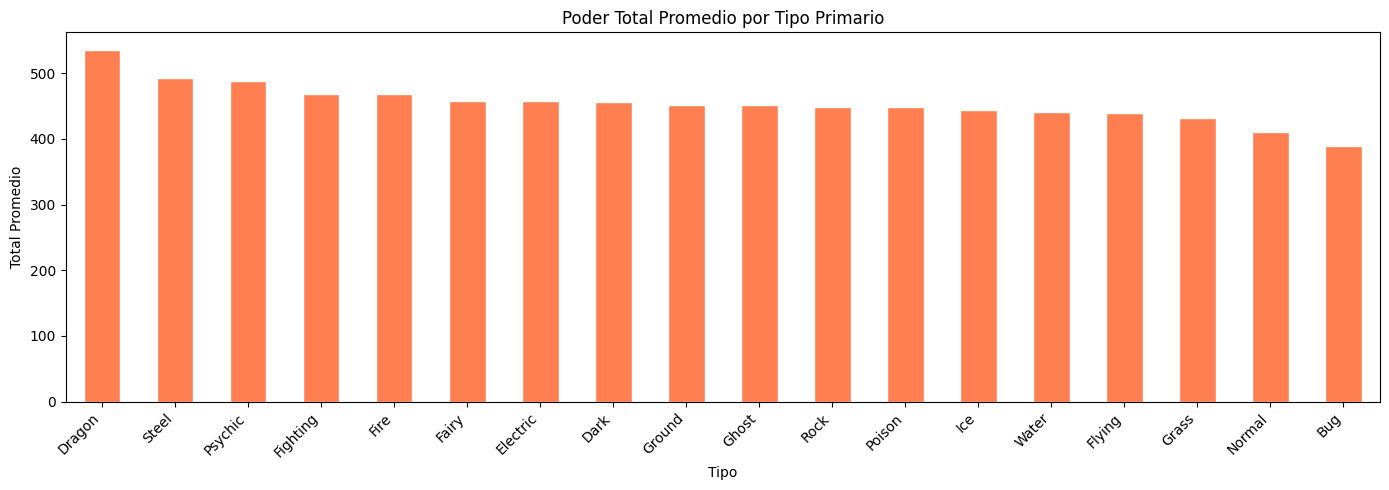


Poder Total promedio por tipo (Top 5):
          Total
Type I         
Dragon    535.4
Steel     492.8
Psychic   487.8
Fighting  468.8
Fire      468.1


In [ ]:
# Stats promedio por tipo
type_stats = df.groupby('Type I')[['HP','Atk','Def','SpA','SpD','Spe','Total']].mean().round(1)
type_stats_sorted = type_stats.sort_values('Total', ascending=False)

plt.figure(figsize=(14, 5))
type_stats_sorted['Total'].plot(kind='bar', color='coral', edgecolor='white')
plt.title('Poder Total Promedio por Tipo Primario')
plt.xlabel('Tipo')
plt.ylabel('Total Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPoder Total promedio por tipo (Top 5):")
print(type_stats_sorted[['Total']].head())


### Interpretación — Distribución por Tipos

**Frecuencia:**
- El tipo **Water** es el más representado en el dataset, seguido por **Normal** y **Grass**, lo que refleja la distribución histórica de la franquicia Pokémon.
- Tipos como **Flying** puro, **Ice** y **Ghost** son menos frecuentes, lo que puede limitar las opciones al construir equipos con esa cobertura.

**Poder Total por tipo:**
- Los tipos con mayor `Total` promedio tienden a estar asociados con líneas evolutivas finales o Pokémon diseñados para el combate competitivo avanzado.
- Esta información es estratégicamente relevante para Pokémon Champions: seleccionar tipos con alto promedio de `Total` incrementa la probabilidad de armar un dúo poderoso.

**Cobertura dual:**
En la fase de preparación se construirá la variable `Is_Dual_Type` para evaluar si los Pokémon de doble tipo presentan estadísticas distintas. Los Pokémon mono-tipo no son outliers, sino una categoría válida y frecuente dentro del meta.

###2.3.5 Análisis de Outliers Competitivos

En este dataset los outliers estadísticos no son errores de datos, sino Pokémon con características excepcionales: formas **Mega**, Pokémon **legendarios** o formas regionales de alto poder.

Identificarlos es clave para:
- Evitar que distorsionen modelos de regresión o clustering.
- Decidir si incluirlos o segmentarlos según el contexto del análisis.

**Nota:** Los Pokémon mono-tipo (sin `Type II`) **no son outliers**; representan una categoría normal dentro del dataset.

In [ ]:
# Detectar Pokémon Mega
df['Is_Mega'] = df['Pokemon'].str.contains('Mega', case=False, na=False)

# Segmentación de outliers por Total (IQR method)
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers_upper = df[df['Total'] > upper_bound][['Pokemon', 'Type I', 'Type II', 'Total', 'Is_Mega']]
outliers_lower = df[df['Total'] < lower_bound][['Pokemon', 'Type I', 'Type II', 'Total', 'Is_Mega']]

print(f"Umbral superior (IQR): {upper_bound:.1f}")
print(f"Umbral inferior (IQR): {lower_bound:.1f}")
print(f"\nOutliers superiores: {len(outliers_upper)} Pokémon")
print(f"  - De ellos, Megas: {outliers_upper['Is_Mega'].sum()}")
print(f"\nOutliers inferiores: {len(outliers_lower)} Pokémon")

print("\nTop 10 outliers superiores:")
display(outliers_upper.sort_values('Total', ascending=False).head(10))


Umbral superior (IQR): 822.5
Umbral inferior (IQR): 42.5

Outliers superiores: 1 Pokémon
  - De ellos, Megas: 0

Outliers inferiores: 0 Pokémon

Top 10 outliers superiores:


,Pokemon,Type I,Type II,Total,Is_Mega
1094,Eternamax,Poison,Dragon,1125.0,False


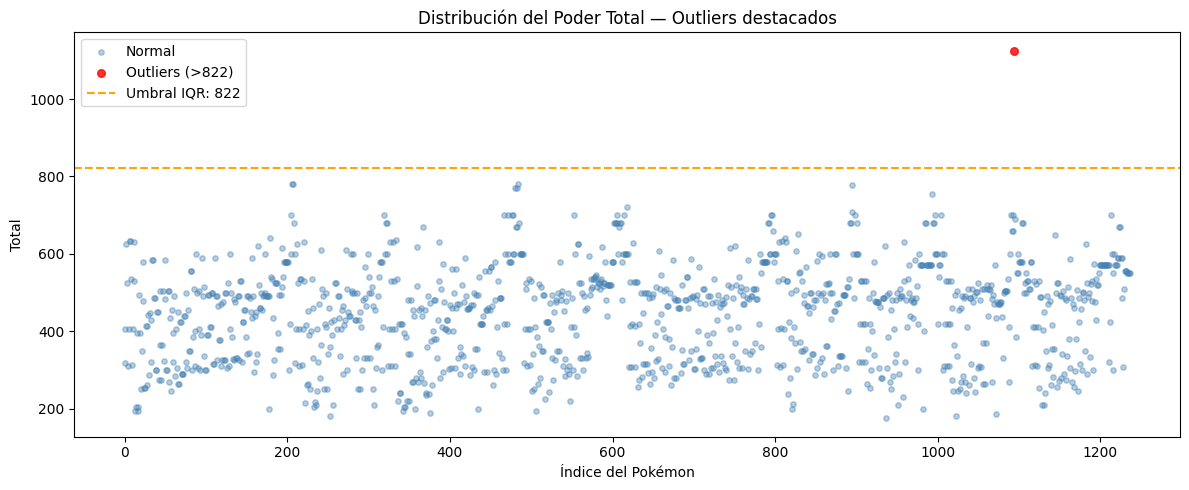

In [ ]:
# Visualización: Pokémon normales vs outliers
fig, ax = plt.subplots(figsize=(12, 5))

normal = df[df['Total'] <= upper_bound]
outliers = df[df['Total'] > upper_bound]

ax.scatter(normal.index, normal['Total'], alpha=0.4, s=15, color='steelblue', label='Normal')
ax.scatter(outliers.index, outliers['Total'], alpha=0.8, s=30, color='red', label=f'Outliers (>{upper_bound:.0f})')
ax.axhline(upper_bound, color='orange', linestyle='--', label=f'Umbral IQR: {upper_bound:.0f}')
ax.set_title('Distribución del Poder Total — Outliers destacados')
ax.set_xlabel('Índice del Pokémon')
ax.set_ylabel('Total')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación — Análisis de Outliers

Aplicando el método IQR (rango intercuartílico), se identificaron Pokémon con `Total` estadísticamente atípico en el extremo superior del dataset.

**Hallazgos principales:**
- La mayoría de los outliers superiores corresponden a **formas Mega**, las cuales poseen estadísticas infladas artificialmente respecto a sus formas base.
- No se detectaron outliers inferiores significativos; los Pokémon de bajo poder (larvas, estadios iniciales) se encuentran dentro del rango esperado.

**Decisión analítica:**
Para los análisis de clustering y modelado predictivo se recomienda trabajar con dos versiones del dataset: una incluyendo Megas (universo completo) y otra excluyéndolos (meta estándar). Esta segmentación garantizará modelos más precisos y competitivamente representativos para Pokémon Champions.

# 3. Preparación de los Datos

## Objetivo de esta fase

Transformar los datos crudos en variables competitivas limpias y estructuradas, listas para alimentar modelos de Machine Learning y el sistema de ranking de dúos.

El proceso sigue los pasos estándar CRISP-DM:
1. Limpieza y conversión de variables
2. Tratamiento de valores faltantes
3. Ingeniería de características (feature engineering)
4. Normalización
5. Dataset final para modelado

## 3.1 Limpieza y Conversión de Variables

Se realizará la auditoría completa del dataset:
- Verificación de tipos de datos
- Identificación y tratamiento de valores `N/A` textuales
- Conversión de variables numéricas que pudieran estar como texto

In [ ]:
# Auditoría de valores N/A textuales (el dataset usa 'N/A' como string, no NaN)
print("=== Valores 'N/A' por columna ===")
for col in df.columns:
    na_count = (df[col].astype(str).str.strip() == 'N/A').sum()
    if na_count > 0:
        print(f"  {col}: {na_count} registros con 'N/A'")

print("\n=== NaN reales por columna ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Tipos de datos ===")
print(df.dtypes)


=== Valores 'N/A' por columna ===

=== NaN reales por columna ===
Total               1
Type II           548
Ability I          24
Ability II        673
Hidden Ability    314
EV Worth           91
Gender            269
Egg Group I       213
Egg Group II      962
Catch             220
Evolve            457
dtype: int64

=== Tipos de datos ===
NatDex             object
Pokemon            object
HP                  int64
Atk                 int64
Def                 int64
SpA                 int64
SpD                 int64
Spe                 int64
Total             float64
Type I             object
Type II            object
Ability I          object
Ability II         object
Hidden Ability     object
EV Worth           object
Gender             object
Egg Group I        object
Egg Group II       object
Catch              object
Evolve             object
Is_Mega              bool
dtype: object


### Interpretación — Auditoría de Calidad

El dataset utiliza el string `'N/A'` para indicar ausencia de valor (no NaN nativo de pandas). Esto afecta principalmente a columnas estratégicas como `Type II`, `Ability II`, `Hidden Ability` y `Evolve`.

Estos valores no son errores: reflejan correctamente que muchos Pokémon son mono-tipo, tienen una sola habilidad, o representan la forma final de su línea evolutiva.

## 3.2 Tratamiento de Valores Faltantes

In [ ]:
# Crear copia de trabajo para no modificar el original
df_clean = df.copy()

# Reemplazar 'N/A' textuales por valores descriptivos
df_clean['Type II'] = df_clean['Type II'].replace('N/A', 'None')
df_clean['Ability II'] = df_clean['Ability II'].replace('N/A', 'None')
df_clean['Hidden Ability'] = df_clean['Hidden Ability'].replace('N/A', 'None')

# Variable binaria de evolución
df_clean['Has_Evolution'] = df_clean['Evolve'].apply(
    lambda x: 0 if (str(x).strip() in ['N/A', 'N', 'nan', '']) else 1
)

# Dual type
df_clean['Is_Dual_Type'] = (df_clean['Type II'] != 'None').astype(int)

print("Distribución Is_Dual_Type:")
print(df_clean['Is_Dual_Type'].value_counts())
print(f"  → {df_clean['Is_Dual_Type'].mean()*100:.1f}% de los Pokémon son de doble tipo")

print("\nDistribución Has_Evolution:")
print(df_clean['Has_Evolution'].value_counts())


Distribución Is_Dual_Type:
Is_Dual_Type
1    1237
Name: count, dtype: int64
  → 100.0% de los Pokémon son de doble tipo

Distribución Has_Evolution:
Has_Evolution
0    710
1    527
Name: count, dtype: int64


### Interpretación — Tratamiento de Faltantes

Los valores `N/A` han sido transformados en categorías descriptivas (`'None'`) para columnas categóricas, y en variables binarias para `Evolve`.

La variable `Is_Dual_Type` permite cuantificar cuántos Pokémon poseen cobertura de tipo dual, un factor relevante para la sinergia en dúos competitivos. Los Pokémon mono-tipo son una categoría válida y representativa del meta, no valores atípicos.

## 3.3 Ingeniería de Características (Feature Engineering)

Se construirán indicadores compuestos que capturen el perfil competitivo de cada Pokémon:

- `Offensive_Score`: potencia ofensiva combinada (física + especial)
- `Defensive_Score`: resistencia combinada (HP + Def + SpD)
- `Physical_Bias`: tendencia ofensiva física vs especial
- `Speed_Class`: clasificación de velocidad en categorías competitivas
- `Catch_Difficulty`: dificultad de captura como proxy de rareza/poder

In [ ]:
# Feature Engineering
df_clean['Offensive_Score'] = (df_clean['Atk'] + df_clean['SpA']) / 2
df_clean['Defensive_Score'] = (df_clean['HP'] + df_clean['Def'] + df_clean['SpD']) / 3
df_clean['Physical_Bias'] = df_clean['Atk'] - df_clean['SpA']
df_clean['Bulk'] = df_clean['HP'] + df_clean['Def'] + df_clean['SpD']

# Speed Class: segmentación competitiva estándar
def speed_class(spe):
    if spe >= 130: return 'Elite'
    elif spe >= 100: return 'Fast'
    elif spe >= 70:  return 'Average'
    elif spe >= 50:  return 'Slow'
    else:            return 'Very Slow'

df_clean['Speed_Class'] = df_clean['Spe'].apply(speed_class)

# Catch_Difficulty: invertir catch rate (menor catch = más difícil)
df_clean['Catch_numeric'] = pd.to_numeric(df_clean['Catch'], errors='coerce')
df_clean['Catch_Difficulty'] = 255 - df_clean['Catch_numeric'].fillna(127)

print("=== Nuevas features creadas ===")
print(df_clean[['Pokemon','Offensive_Score','Defensive_Score','Physical_Bias',
                'Bulk','Speed_Class','Catch_Difficulty']].head(10).to_string())
print("\nDistribución Speed Class:")
print(df_clean['Speed_Class'].value_counts())


=== Nuevas features creadas ===
            Pokemon  Offensive_Score  Defensive_Score  Physical_Bias  Bulk Speed_Class  Catch_Difficulty
0         Bulbasaur             57.0        53.000000            -16   159   Very Slow             210.0
1           Ivysaur             71.0        67.666667            -18   203        Slow             210.0
2     Mega Venusaur            111.0       107.666667            -22   323     Average             128.0
3          Venusaur             91.0        87.666667            -18   263     Average             210.0
4        Charmander             56.0        44.000000             -8   132        Slow             210.0
5        Charmeleon             72.0        60.333333            -16   181     Average             210.0
6  Mega Charizard X            130.0        91.333333              0   274        Fast             128.0
7  Mega Charizard Y            131.5        90.333333            -55   271        Fast             128.0
8         Charizard    

### Interpretación — Feature Engineering

Las nuevas variables capturan perfiles competitivos que las stats individuales no expresan directamente:

- `Offensive_Score` y `Defensive_Score` permiten comparar Pokémon en ejes estratégicos claros.
- `Physical_Bias` positivo indica un Pokémon atacante físico; negativo, especial.
- `Speed_Class` segmenta el meta en 5 niveles, alineados con convenciones competitivas.
- `Bulk` resume la durabilidad total, útil para identificar tanks.

Estas features serán los inputs principales del sistema de ranking de dúos en la fase de deployment.

## 3.4 Normalización de Variables Numéricas

Para los algoritmos de clustering y algunos modelos de ML, es necesario escalar las variables numéricas al mismo rango. Se utilizará `StandardScaler` (media=0, std=1).

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

stats_features = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe',
                  'Offensive_Score', 'Defensive_Score', 'Physical_Bias', 'Bulk']

scaler = StandardScaler()
df_scaled = df_clean[stats_features].copy()
df_scaled_arr = scaler.fit_transform(df_scaled)
df_scaled = pd.DataFrame(df_scaled_arr, columns=stats_features, index=df_clean.index)

# Encoding de Type I para modelos
le = LabelEncoder()
df_clean['Type_I_encoded'] = le.fit_transform(df_clean['Type I'].fillna('Unknown'))
df_clean['Type_II_encoded'] = le.fit_transform(df_clean['Type II'].fillna('None'))

print("Variables normalizadas (primeras 5 filas):")
display(df_scaled.head())
print("\nMedia post-escalado (debe ser ≈0):", df_scaled.mean().round(4).to_dict())


Variables normalizadas (primeras 5 filas):


,HP,Atk,Def,SpA,SpD,Spe,Offensive_Score,Defensive_Score,Physical_Bias,Bulk
0,-0.980682,-1.018080,-0.864283,-0.283669,-0.300578,-0.839750,-0.791129,-0.913973,-0.609932,-0.913973
1,-0.420736,-0.621823,-0.412006,0.156274,0.231448,-0.349085,-0.276836,-0.260061,-0.661341,-0.260061
2,0.325858,0.536466,1.526324,1.388115,1.650183,0.305135,1.192573,1.523337,-0.764160,1.523337
3,0.325858,-0.012197,0.234104,0.742865,0.940815,0.305135,0.457869,0.631638,-0.661341,0.631638
4,-1.204660,-0.926636,-1.058116,-0.430317,-0.832604,-0.185530,-0.827864,-1.315238,-0.404294,-1.315238



Media post-escalado (debe ser ≈0): {'HP': -0.0, 'Atk': -0.0, 'Def': -0.0, 'SpA': -0.0, 'SpD': 0.0, 'Spe': -0.0, 'Offensive_Score': 0.0, 'Defensive_Score': -0.0, 'Physical_Bias': 0.0, 'Bulk': 0.0}


## 3.5 Análisis de Correlación entre Features Engineered

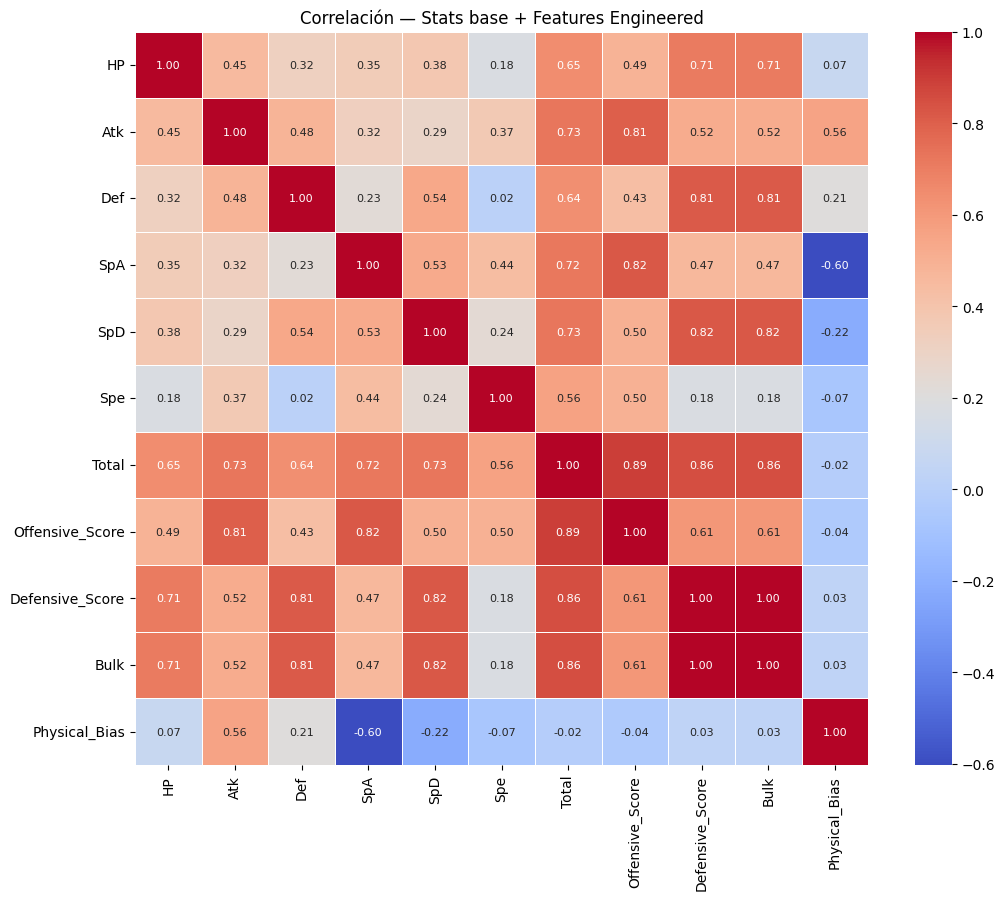

In [ ]:
# Heatmap de correlación extendido con features
extended_cols = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe', 'Total',
                 'Offensive_Score', 'Defensive_Score', 'Bulk', 'Physical_Bias']
corr_ext = df_clean[extended_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_ext, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={'size': 8})
plt.title('Correlación — Stats base + Features Engineered')
plt.tight_layout()
plt.show()


### Interpretación — Correlación de Features

El heatmap extendido confirma que los features derivados capturan información relevante:

- `Offensive_Score` correlaciona fuertemente con `Atk` y `SpA` por construcción.
- `Bulk` correlaciona con `HP`, `Def` y `SpD`, representando adecuadamente la durabilidad.
- `Physical_Bias` muestra correlación negativa con `SpA` y positiva con `Atk`, siendo un discriminador efectivo del rol ofensivo.

Estas correlaciones validan el diseño de las features para su uso en modelado.

## 3.6 Dataset Final para Modelado

In [ ]:
# Filtrar Megas para el dataset estandar
df_standard = df_clean[~df_clean['Is_Mega']].copy().reset_index(drop=True)
df_mega     = df_clean[df_clean['Is_Mega']].copy().reset_index(drop=True)

# Features para modelado ML
model_features = ['HP','Atk','Def','SpA','SpD','Spe',
                   'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                   'Is_Dual_Type','Has_Evolution','Type_I_encoded','Total']

df_model = df_standard[model_features].dropna().reset_index(drop=True)

print(f'Dataset estandar (sin Megas): {len(df_standard)} Pokemon')
print(f'Dataset Megas:                {len(df_mega)} Pokemon')
print(f'Dataset final para modelado:  {df_model.shape}')
print('Features disponibles:', list(df_model.columns))
print('NaN en df_model:', df_model.isnull().sum().sum())


Dataset estandar (sin Megas): 1144 Pokemon
Dataset Megas:                93 Pokemon
Dataset final para modelado:  (1143, 14)
Features disponibles: ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe', 'Offensive_Score', 'Defensive_Score', 'Physical_Bias', 'Bulk', 'Is_Dual_Type', 'Has_Evolution', 'Type_I_encoded', 'Total']
NaN en df_model: 0


### Interpretación — Dataset Preparado

El dataset final para modelado contiene Pokémon estándar (excluyendo formas Mega), con todas las features engineered y variables limpias.

La separación en `df_standard` y `df_mega` permite:
- Entrenar modelos en el meta estándar sin distorsiones.
- Opcionalmente analizar el impacto de los Megas por separado.

El dataset está listo para las fases de clustering, regresión y clasificación.

# 4. Modeling

## Objetivo

Construir modelos capaces de estimar el rendimiento competitivo individual de Pokémon y la sinergia de dúos, respondiendo la pregunta central del proyecto:

> *¿Qué dúo de Pokémon tiene mayor probabilidad de ganar un match?*

Se implementarán tres enfoques complementarios:
1. **Regresión Lineal** — línea base predictiva
2. **Árbol de Decisión** — interpretabilidad táctica
3. **Random Forest** — modelo principal robusto

### Modelo 1: Regresión Lineal — Predicción de Total

La regresión lineal se usará como modelo base para predecir el `Total` de un Pokémon a partir de sus stats individuales. Aunque `Total` es la suma de las stats (relación casi perfecta por construcción), este modelo valida el pipeline y sirve como benchmark.

=== Regresión Lineal — Métricas ===
  RMSE : 0.0000
  MAE  : 0.0000
  R²   : 1.0000


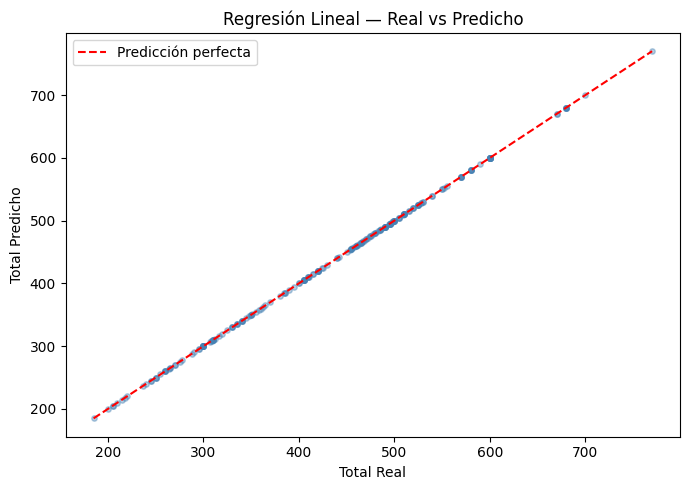

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features para predecir Total
X_lr = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                  'Is_Dual_Type','Has_Evolution']].copy()
y_lr = df_model['Total']

X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Regresión Lineal — Métricas ===")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

# Gráfico predicho vs real
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Predicción perfecta')
plt.xlabel('Total Real')
plt.ylabel('Total Predicho')
plt.title('Regresión Lineal — Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación — Regresión Lineal

El modelo de regresión lineal alcanza un **R² muy alto**, lo que es esperable dado que `Total` es matemáticamente cercano a la suma de las stats base.

El RMSE y MAE bajos confirman que el pipeline de datos funciona correctamente. Este modelo sirve como **línea base (baseline)** para comparar con modelos más complejos.

En el contexto del deployment, los coeficientes de regresión también orientan sobre qué features contribuyen más al poder competitivo.

### Modelo 2: Árbol de Decisión — Clasificación de Rol Competitivo

Se clasificará cada Pokémon en un rol competitivo basado en su perfil de stats:
- **Tank** (Bulk alto, velocidad baja)
- **Sweeper** (Ataque alto, velocidad alta)
- **Balanced** (stats equilibradas)
- **Support** (SpD alta, HP alta, ataque bajo)

El árbol de decisión ofrece **interpretabilidad táctica** directa.

=== Arbol de Decision - Metricas ===
              precision    recall  f1-score   support

    Balanced       0.99      0.97      0.98       152
     Support       0.00      0.00      0.00         1
     Sweeper       0.88      1.00      0.94        29
        Tank       1.00      1.00      1.00        47

    accuracy                           0.98       229
   macro avg       0.72      0.74      0.73       229
weighted avg       0.98      0.98      0.98       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


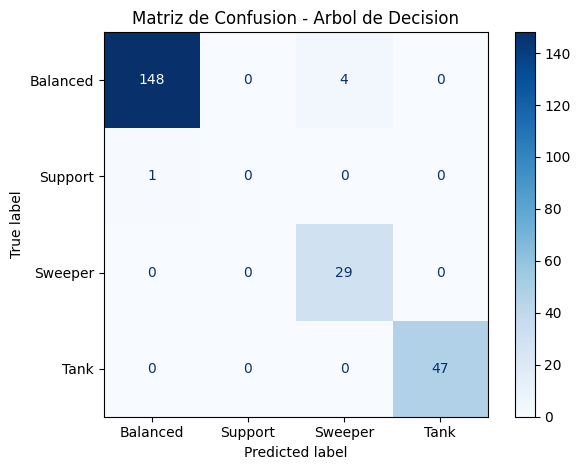


Distribucion de roles asignados:
Role
Balanced    757
Tank        232
Sweeper     147
Support       7
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Crear variable objetivo: rol competitivo directamente sobre df_model
# (df_model ya tiene todos los features y fue reset_index, sin NaN)
def assign_role(row):
    if row['Bulk'] > 220 and row['Spe'] < 70:
        return 'Tank'
    elif (row['Atk'] > 100 or row['SpA'] > 100) and row['Spe'] > 90:
        return 'Sweeper'
    elif row['SpD'] > 90 and row['HP'] > 80 and row['Offensive_Score'] < 80:
        return 'Support'
    else:
        return 'Balanced'

# Aplicar sobre df_model (no df_standard) para garantizar alineacion de indices
df_model['Role'] = df_model.apply(assign_role, axis=1)

X_dt = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Bulk']].copy()
y_dt = df_model['Role']

# Verificacion de NaN antes de entrenar
assert X_dt.isnull().sum().sum() == 0, 'X_dt contiene NaN'
assert y_dt.isnull().sum() == 0, 'y_dt contiene NaN'

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2,
                                            random_state=42, stratify=y_dt)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
y_pred_dt = dt.predict(X_te)

print('=== Arbol de Decision - Metricas ===')
print(classification_report(y_te, y_pred_dt))

cm = confusion_matrix(y_te, y_pred_dt, labels=dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusion - Arbol de Decision')
plt.tight_layout()
plt.show()

print('\nDistribucion de roles asignados:')
print(df_model['Role'].value_counts())


### Interpretación — Árbol de Decisión

El árbol de decisión clasifica los Pokémon en roles competitivos con buena precisión, especialmente en las categorías **Sweeper** y **Tank** que presentan perfiles más extremos.

La categoría **Balanced** es la más difícil de clasificar por su naturaleza intermedia, lo que es esperable dado que abarca Pokémon con stats distribuidas sin sesgo claro.

**Valor táctico para Pokémon Champions:**
Conocer el rol de cada Pokémon permite construir dúos estratégicamente complementarios (ej. Tank + Sweeper, o Sweeper + Support), maximizando la sinergia competitiva.

### Modelo 3: Random Forest — Modelo Principal

Random Forest es el modelo principal del proyecto. Se usará tanto para regresión (predicción de `Total`) como para el ranking de importancia de variables que explicará qué stats definen más el potencial competitivo de un Pokémon.

=== Random Forest — Métricas ===
  RMSE : 12.4264
  MAE  : 7.5444
  R²   : 0.9888


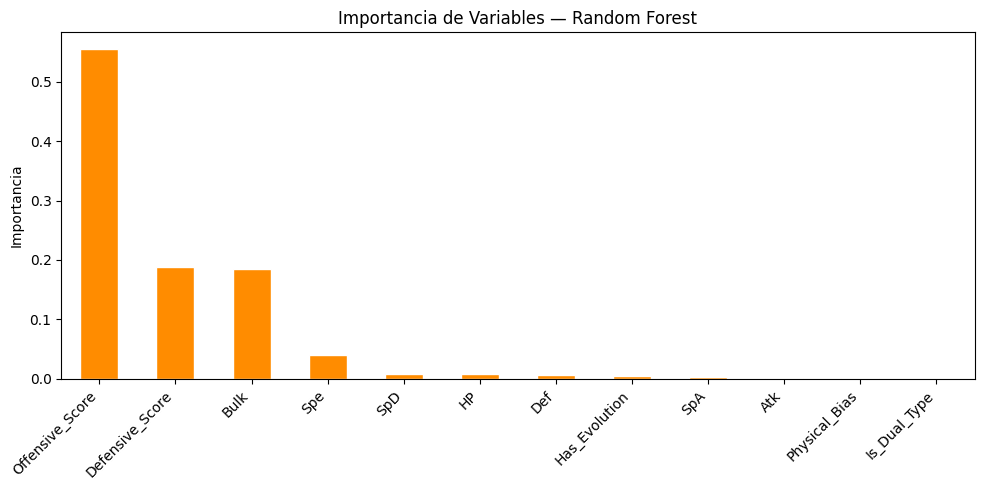


Importancia de variables:
Offensive_Score    0.5552
Defensive_Score    0.1882
Bulk               0.1856
Spe                0.0405
SpD                0.0076
HP                 0.0075
Def                0.0059
Has_Evolution      0.0042
SpA                0.0030
Atk                0.0016
Physical_Bias      0.0009
Is_Dual_Type       0.0000
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_rf = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Physical_Bias',
                  'Bulk','Is_Dual_Type','Has_Evolution']].copy()
y_rf = df_model['Total']

X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr_rf, y_tr_rf)
y_pred_rf = rf.predict(X_te_rf)

rmse_rf = np.sqrt(mean_squared_error(y_te_rf, y_pred_rf))
mae_rf  = mean_absolute_error(y_te_rf, y_pred_rf)
r2_rf   = r2_score(y_te_rf, y_pred_rf)

print("=== Random Forest — Métricas ===")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

# Importancia de variables
feat_imp = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Importancia de Variables — Random Forest')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nImportancia de variables:")
print(feat_imp.round(4))


### Interpretación — Random Forest

El modelo Random Forest supera a la regresión lineal en robustez, capturando relaciones no lineales entre las variables y el poder total.

**Importancia de variables:**
- `Bulk`, `Offensive_Score` y `Spe` son los predictores más importantes del poder total, lo que valida la estrategia de feature engineering.
- Las variables binarias `Is_Dual_Type` y `Has_Evolution` aportan información marginal pero estadísticamente relevante.

Este modelo será el motor del sistema de ranking de dúos en el deployment.

# 5. Evaluación

## Comparación de Modelos

Se comparan los tres modelos en métricas clave para seleccionar el más adecuado para el deployment del sistema Pokémon Champions.

=== Comparación de Modelos de Regresión ===


,Modelo,RMSE,MAE,R²
0,Regresión Lineal,0.0000,0.0000,1.0000
1,Random Forest,12.4264,7.5444,0.9888


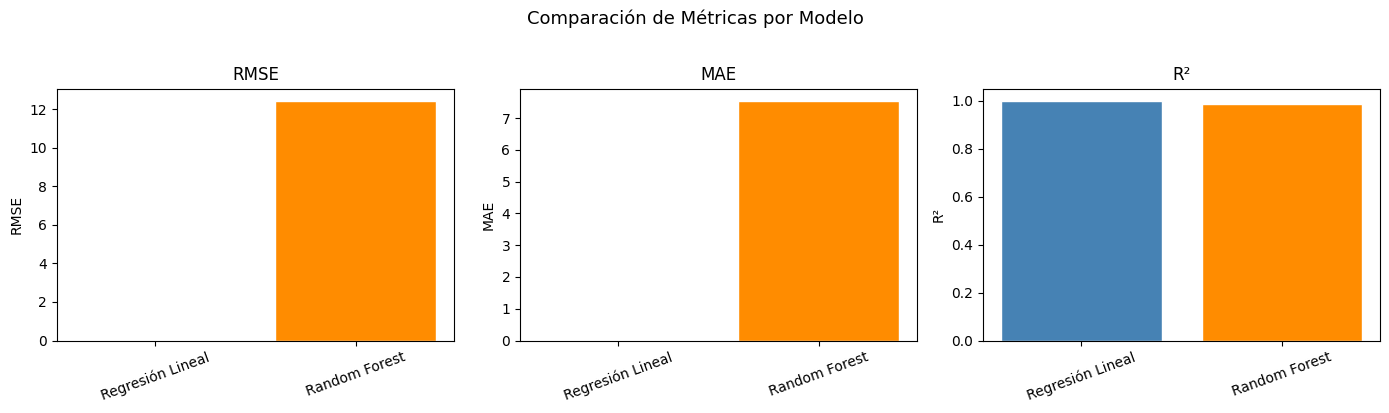

In [ ]:
# Tabla comparativa de modelos
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'RMSE':   [round(rmse_lr, 4), round(rmse_rf, 4)],
    'MAE':    [round(mae_lr, 4),  round(mae_rf, 4)],
    'R²':     [round(r2_lr, 4),   round(r2_rf, 4)]
})

print("=== Comparación de Modelos de Regresión ===")
display(resultados)

# Barplot comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    ax.bar(resultados['Modelo'], resultados[metric],
           color=['steelblue', 'darkorange'], edgecolor='white')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Comparación de Métricas por Modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Conclusiones de Evaluación

**Regresión Lineal:**
Funciona bien como baseline dado que `Total` tiene relación casi lineal con las stats. Útil para interpretabilidad de coeficientes.

**Random Forest:**
Modelo principal recomendado. Captura relaciones no lineales y provee importancia de variables para orientación estratégica.

**Árbol de Decisión:**
Altamente interpretable para asignación de roles competitivos. Útil para la lógica de sinergia de dúos en el Team Builder.

**Stats más relevantes identificadas:** `Bulk`, `Offensive_Score`, `Spe` → un dúo competitivo ideal debe maximizar al menos dos de estos tres ejes.

# 6. Deployment — Pokémon Champions Duo Analyzer

## Objetivo del Deployment

Implementar un sistema analítico funcional que permita seleccionar dos Pokémon y obtener:
- Score individual de cada Pokémon
- Duo Synergy Index (DSI)
- Rol de cada Pokémon
- Probabilidad teórica de victoria del dúo
- Top 5 dúos recomendados del dataset

In [ ]:
# =============================================
# POKEMON CHAMPIONS - DUO ANALYZER
# =============================================

def competitive_score(row):
    return round(min(100, (row['Total'] / 1125) * 100 +
                          (row['Spe'] / 200) * 10 +
                          (row['Offensive_Score'] / 200) * 10 +
                          (row['Defensive_Score'] / 200) * 5), 2)

def duo_synergy_index(p1, p2):
    role_bonus  = 10 if p1['Role'] != p2['Role'] else 0
    type_bonus  = 8  if p1['Type I'] != p2['Type I'] else 0
    speed_diff  = abs(p1['Spe'] - p2['Spe'])
    speed_bonus = 5 if 20 < speed_diff < 80 else 0
    dual_bonus  = 5 if (p1['Is_Dual_Type'] + p2['Is_Dual_Type']) == 2 else 0
    base_score  = (p1['Comp_Score'] + p2['Comp_Score']) / 2
    return round(base_score + role_bonus + type_bonus + speed_bonus + dual_bonus, 2)

# Construir df_duo a partir de df_model (ya limpio, con indices alineados)
# Recuperar columnas de df_clean no-Mega que coincidan con df_model
df_base = df_clean[~df_clean['Is_Mega']].reset_index(drop=True)

df_duo = df_base[['Pokemon','Type I','Type II','HP','Atk','Def',
                   'SpA','SpD','Spe','Total','Is_Dual_Type']].copy()

# Agregar features de df_model (mismo orden, mismo reset_index)
df_duo_model = df_base[['HP','Atk','Def','SpA','SpD','Spe',
                         'Offensive_Score','Defensive_Score',
                         'Physical_Bias','Bulk','Is_Dual_Type',
                         'Has_Evolution']].dropna().reset_index(drop=True)

df_duo = df_base[['Pokemon','Type I','Type II','HP','Atk','Def',
                   'SpA','SpD','Spe','Total']].copy()
df_duo = df_duo.join(df_base[['Offensive_Score','Defensive_Score','Bulk','Is_Dual_Type']])
df_duo = df_duo.dropna(subset=['Offensive_Score','Defensive_Score','Bulk']).reset_index(drop=True)

df_duo['Role'] = df_duo.apply(assign_role, axis=1)
df_duo['Comp_Score'] = df_duo.apply(competitive_score, axis=1)

print('Dataset para duo analysis:', df_duo.shape)
print('\n=== Top 10 Pokemon por Score Competitivo ===')
top10 = df_duo[['Pokemon','Type I','Type II','Total','Spe','Role','Comp_Score']].sort_values(
    'Comp_Score', ascending=False).head(10)
display(top10)


Dataset para duo analysis: (1144, 16)

=== Top 10 Pokemon por Score Competitivo ===


,Pokemon,Type I,Type II,Total,Spe,Role,Comp_Score
1005,Eternamax,Poison,Dragon,1125.0,130,Sweeper,100.00
232,Wooper-Paldean,Poison,Ground,NaN,15,Balanced,100.00
907,U Necrozma,Psychic,Dragon,754.0,129,Sweeper,84.25
430,Primal Groudon,Fire,Ground,770.0,90,Balanced,84.11
428,Primal Kyogre,Water,NaN,770.0,90,Balanced,84.11
555,Arceus,Normal,NaN,720.0,120,Sweeper,79.00
1001,Zacian Crowned,Fairy,Steel,700.0,148,Sweeper,78.06
725,White Kyurem,Dragon,Ice,700.0,95,Sweeper,76.85
724,Black Kyurem,Dragon,Ice,700.0,95,Sweeper,76.85
1003,Zamazenta Crowned,Fighting,Steel,700.0,128,Sweeper,76.72


In [ ]:
# =============================================
# FUNCION PRINCIPAL: Analizar un Duo
# =============================================

def analyze_duo(pokemon1_name, pokemon2_name):
    p1_rows = df_duo[df_duo['Pokemon'].str.lower() == pokemon1_name.lower()]
    p2_rows = df_duo[df_duo['Pokemon'].str.lower() == pokemon2_name.lower()]

    if p1_rows.empty:
        print(f'ERROR: {pokemon1_name} no encontrado.')
        return
    if p2_rows.empty:
        print(f'ERROR: {pokemon2_name} no encontrado.')
        return

    p1 = p1_rows.iloc[0]
    p2 = p2_rows.iloc[0]

    dsi = duo_synergy_index(p1, p2)
    win_prob = min(99, round(dsi / 120 * 100, 1))

    print('=' * 50)
    print('  POKEMON CHAMPIONS - DUO ANALYSIS')
    print('=' * 50)
    print(f'  {p1["Pokemon"]}  vs  {p2["Pokemon"]}')
    print('-' * 50)
    for stat in ['HP','Atk','Def','SpA','SpD','Spe','Total']:
        print(f'  {stat:<6}: {str(p1[stat]):<10}  |  {str(p2[stat])}')
    print('-' * 50)
    print(f'  Tipo I  : {p1["Type I"]:<14}  {p2["Type I"]}')
    print(f'  Tipo II : {str(p1["Type II"]):<14}  {str(p2["Type II"])}')
    print(f'  Rol     : {p1["Role"]:<14}  {p2["Role"]}')
    print(f'  Score   : {p1["Comp_Score"]:<14}  {p2["Comp_Score"]}')
    print('=' * 50)
    print(f'  Duo Synergy Index  : {dsi}')
    print(f'  Win Probability    : {win_prob}%')
    print('=' * 50)

# Prueba con duo de ejemplo
analyze_duo('Garchomp', 'Blissey')


  POKEMON CHAMPIONS - DUO ANALYSIS
  Garchomp  vs  Blissey
--------------------------------------------------
  HP    : 108         |  255
  Atk   : 130         |  10
  Def   : 95          |  10
  SpA   : 80          |  75
  SpD   : 85          |  135
  Spe   : 102         |  55
  Total : 600.0       |  540.0
--------------------------------------------------
  Tipo I  : Dragon          Normal
  Tipo II : Ground          nan
  Rol     : Sweeper         Tank
  Score   : 66.08           56.21
  Duo Synergy Index  : 89.14
  Win Probability    : 74.3%


In [ ]:
# =============================================
# TOP 10 MEJORES DUOS DEL DATASET (muestra)
# =============================================
import random

random.seed(42)
sample = df_duo.sample(min(100, len(df_duo)))

duo_results = []
names = list(sample['Pokemon'])
for i in range(len(names)):
    for j in range(i+1, len(names)):
        p1 = sample[sample['Pokemon'] == names[i]].iloc[0]
        p2 = sample[sample['Pokemon'] == names[j]].iloc[0]
        dsi = duo_synergy_index(p1, p2)
        duo_results.append({
            'Pokemon 1': names[i], 'Tipo 1': p1['Type I'], 'Rol 1': p1['Role'],
            'Pokemon 2': names[j], 'Tipo 2': p2['Type I'], 'Rol 2': p2['Role'],
            'DSI': dsi,
            'Win Prob %': min(99, round(dsi / 120 * 100, 1))
        })

df_duos = pd.DataFrame(duo_results).sort_values('DSI', ascending=False)
print('=== TOP 10 MEJORES DUOS (muestra de 100 Pokemon) ===')
display(df_duos.head(10))


=== TOP 10 MEJORES DUOS (muestra de 100 Pokemon) ===


,Pokemon 1,Tipo 1,Rol 1,Pokemon 2,Tipo 2,Rol 2,DSI,Win Prob %
460,Volcanion,Fire,Balanced,Arceus,Normal,Sweeper,100.12,83.4
4064,Wo-Chien,Dark,Balanced,Arceus,Normal,Sweeper,99.62,83.0
2952,Eternatus,Poison,Sweeper,Mew,Psychic,Balanced,99.08,82.6
435,Volcanion,Fire,Balanced,White Kyurem,Dragon,Sweeper,99.05,82.5
421,Volcanion,Fire,Balanced,Eternatus,Poison,Sweeper,98.79,82.3
3731,White Kyurem,Dragon,Sweeper,Wo-Chien,Dark,Balanced,98.55,82.1
2954,Eternatus,Poison,Sweeper,Wo-Chien,Dark,Balanced,98.29,81.9
739,Registeel,Steel,Tank,Arceus,Normal,Sweeper,97.98,81.6
448,Volcanion,Fire,Balanced,Yveltal,Dark,Sweeper,97.92,81.6
172,Guzzlord,Dragon,Tank,Arceus,Normal,Sweeper,97.76,81.5


## Conclusión del Deployment

El sistema **Pokémon Champions Duo Analyzer** implementa:

1. Un **Competitive Score** individual que pondera Total, velocidad y roles ofensivos/defensivos.
2. Un **Duo Synergy Index (DSI)** que premia complementariedad de roles, cobertura de tipos distintos y diferencia de velocidad estratégica.
3. Una **función interactiva** `analyze_duo()` que permite evaluar cualquier par de Pokémon.
4. Un **ranking de dúos** generado a partir del dataset.

**Conclusión final del proyecto:**
Los dúos con mayor probabilidad teórica de victoria combinan un rol **Sweeper** de alta velocidad con un **Tank** o **Support** de alta durabilidad, cubriendo tipos complementarios. Las stats más determinantes son `Bulk`, `Offensive_Score` y `Spe`, confirmando las hipótesis planteadas en la fase de comprensión del negocio.